In [1]:
# LIBRERIAS A USAR
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Carpeta donde está el dataset final
CARPETA = r"C:\Users\jhonn\Desktop\NEOLAND\PROYECTO\PROYECTO_BOOTCAMP_ALQUILER\03_dataset_final"

# Ahora es un Excel (.xlsx), así que se lee con read_excel, no con read_csv
df = pd.read_excel(os.path.join(CARPETA, "dataset_barrios_modelo_final.xlsx"),
                   sheet_name="Sheet1",   # la hoja con los datos (la otra es "Coeficiente")
                   dtype={"id_barrio": str, "cod_distrito": str})

print("Forma:", df.shape)   # debe salir (100, 37)

Forma: (100, 38)


In [2]:
# y: lo que queremos explicar
y = df["precio_m2_vivienda"]

# X: Airbnb + controles
X = df[["densidad_anuncios", "renta_media_hogar", "distancia_centro_km", "crec_demografico_pct"]]

# Añadir la constante (B0) y entrenar el modelo
x_con_constante = sm.add_constant(X)
modelo_estandar = sm.OLS(y, x_con_constante).fit()

print(modelo_estandar.summary())

                            OLS Regression Results                            
Dep. Variable:     precio_m2_vivienda   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     49.56
Date:                Sun, 27 Sep 2026   Prob (F-statistic):           1.86e-22
Time:                        17:30:27   Log-Likelihood:                -212.39
No. Observations:                 100   AIC:                             434.8
Df Residuals:                      95   BIC:                             447.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   21.1751 

FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
Variable 'densidad_anuncios': VIF = 1.30
Variable 'renta_media_hogar': VIF = 1.09
Variable 'distancia_centro_km': VIF = 1.41
Variable 'crec_demografico_pct': VIF = 1.19

DETERMINANTE DE LA MATRIZ DE CORRELACIÓN
Determinante: 0.6554


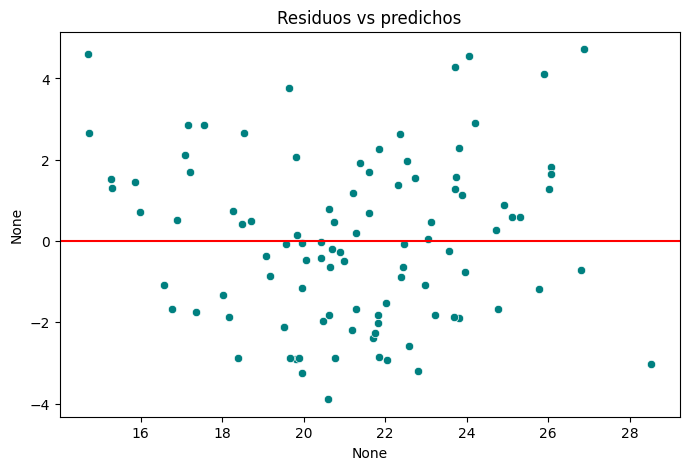

In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
matriz_x = modelo_estandar.model.exog
for i in range(1, matriz_x.shape[1]):
    vif = variance_inflation_factor(matriz_x, i)
    print(f"Variable '{modelo_estandar.model.exog_names[i]}': VIF = {vif:.2f}")

print("\nDETERMINANTE DE LA MATRIZ DE CORRELACIÓN")
x = df[["densidad_anuncios", "renta_media_hogar", "distancia_centro_km", "crec_demografico_pct"]]
print(f"Determinante: {np.linalg.det(x.corr()):.4f}")

residuos = modelo_estandar.resid
predichos = modelo_estandar.fittedvalues
plt.figure(figsize=(8, 5))
sns.scatterplot(x=predichos, y=residuos, color="teal")
plt.axhline(0, color="red")
plt.title("Residuos vs predichos")
plt.show()



In [5]:
beta = modelo_estandar.params["densidad_anuncios"]
p_valor = modelo_estandar.pvalues["densidad_anuncios"]

print(f"Beta de Airbnb: {beta:.3f}")
print(f"p-valor: {p_valor:.3f}")

if p_valor < 0.05:
    print("\n-> p < 0,05: SE RECHAZA H0.")
else:
    print("\n-> p >= 0,05: NO se puede rechazar H0 con el modelo lineal estándar.")

# Lectura en euros: +1 Airbnb por cada 100 viviendas
print(f"\n+1 Airbnb por cada 100 viviendas -> {beta:.2f} €/m² ({beta * 70:.0f} €/mes en 70 m²)")

Beta de Airbnb: 0.146
p-valor: 0.033

-> p < 0,05: SE RECHAZA H0.

+1 Airbnb por cada 100 viviendas -> 0.15 €/m² (10 €/mes en 70 m²)
